# BA

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots, MCSamples

# ============================================================
# 1. Load samples
# ============================================================

# Load chains data for CPL model
data1 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt')
data2 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt')
data3 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt') 

# Extract weights (column 0)
weights1 = data1[:, 0]
weights2 = data2[:, 0]
weights3 = data3[:, 0]

# Extract cosmological parameters (columns 2-6: Om, Obh2, h, w0, wa)
params1 = data1[:, 2:7]
params2 = data2[:, 2:7]
params3 = data3[:, 2:7]

# Define parameter names and labels
param_names = ['Om', 'Obh2', 'h', 'w0', 'wa']
param_labels = [r'\Omega_m', r'\Omega_b h^2', r'h', r'w_0', r'w_a']

# Create MCSamples objects
samples1 = MCSamples(samples=params1, weights=weights1, names=param_names, labels=param_labels)
samples2 = MCSamples(samples=params2, weights=weights2, names=param_names, labels=param_labels)
samples3 = MCSamples(samples=params3, weights=weights3, names=param_names, labels=param_labels)

samples_list = [samples1, samples2, samples3]

labels = [
    "PLK18+DESIDR2+PantheonPlus",
    "PLK18+DESIDR2+Union3",
    "PLK18+DESIDR2+DESY5"
]

Removed no burn in
Removed no burn in
Removed no burn in


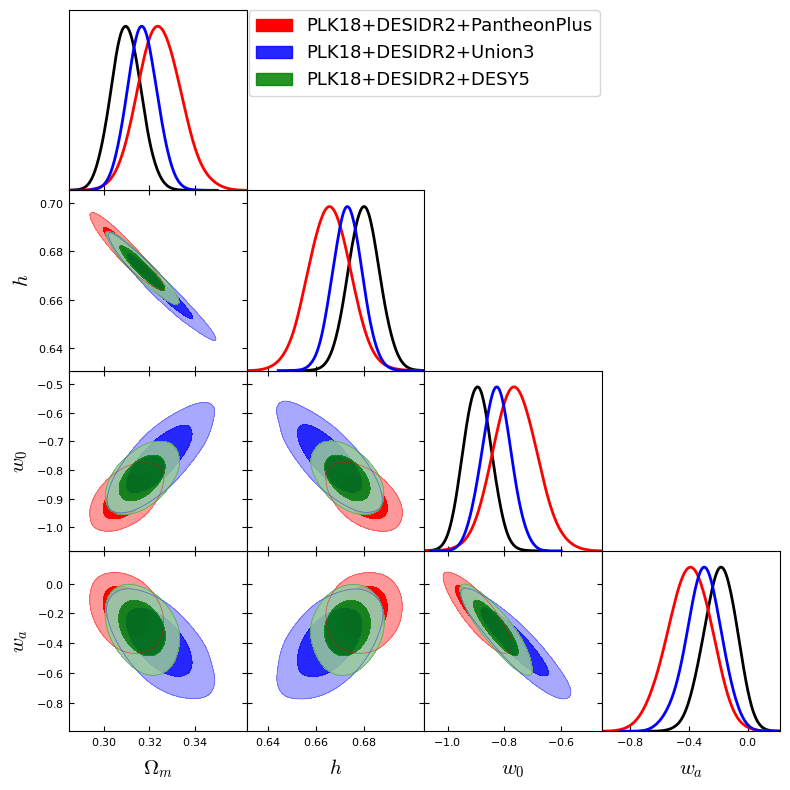

In [5]:
# ============================================================
# 2. Triangle plot
# ============================================================

params = ['Om', 'h', 'w0', 'wa']

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize  = 18
g.settings.lab_fontsize   = 18

g.triangle_plot(
    samples_list,
    params,
    filled=True,
    legend_labels=labels,
    contour_colors=["red", "blue", "green"],
    line_args=[
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2}
    ]
)

plt.savefig("combined_ba_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
import glob

# Adjust these paths to your actual chain root names
chain_roots = {
    "PLK18+DESIDR2+PantheonPlus": "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1",
    "PLK18+DESIDR2+Union3":       "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1",
    "PLK18+DESIDR2+DESY5":        "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1",
}

def get_chi2_min_from_files(chain_root):
    files = sorted(glob.glob(chain_root + "_*.txt"))
    if not files:
        # try without numbering
        files = [chain_root + ".txt"]
    print(f"  Found {len(files)} chain file(s): {files}")
    
    all_loglikes = []
    for f in files:
        raw = np.loadtxt(f)
        all_loglikes.append(raw[:, 1])   # column 1 = -loglike
    
    combined = np.concatenate(all_loglikes)
    return 2.0 * np.min(combined)

# ============================================================
# ============================================================
# 4. Model complexity and data size
# ============================================================

# Number of free parameters in ΛCDM
k_ba = 4   # H0, Omegab0, Omegam0, od0

# Number of data points
N_values = {
    "PLK18+DESIDR2+PantheonPlus": 1701 + 0 + 13,   # 1717
    "PLK18+DESIDR2+Union3":   1829 + 0 + 13,   # 1845
    "PLK18+DESIDR2+DESY5":            0 + 13 + 2087          # 16
}

results = []
for label in labels:
    print(f"\n{label}")
    chi2_min = get_chi2_min_from_files(chain_roots[label])
    N = N_values[label]
    AIC = chi2_min + 2 * k_ba
    BIC = chi2_min + k_ba * np.log(N)
    results.append((label, chi2_min, AIC, BIC))
    print(f"chi2_min = {chi2_min:.3f}")
    print(f"AIC      = {AIC:.3f}")
    print(f"BIC      = {BIC:.3f}")
    
    # ---- Text file ----
with open("cpl_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

# ---- LaTeX table ----
with open("cpl_AIC_BIC.tex", "w") as f:
    f.write(r"\begin{tabular}{lccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & $\chi^2_{\min}$ & AIC & BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label} & {chi2:.2f} & {aic:.2f} & {bic:.2f} \\\\\n")
    f.write(r"\hline" + "\n")
    f.write(r"\end{tabular}" + "\n")

# ============================================================
# 7. Print selected parameter constraints
# ============================================================
'Om', 'h', 'w0', 'wa'
for s, l in zip(samples_list, labels):
    print(f"\nParameter constraints for {l}:")
    print(s.getInlineLatex('Om', limit=1))
    print(s.getInlineLatex('h', limit=1))
    print(s.getInlineLatex('w0', limit=1))
    print(s.getInlineLatex('wa', limit=1))


PLK18+DESIDR2+PantheonPlus
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt']
chi2_min = 1411.520
AIC      = 1419.520
BIC      = 1441.306

PLK18+DESIDR2+Union3
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt']
chi2_min = 28.973
AIC      = 36.973
BIC      = 59.048

PLK18+DESIDR2+DESY5
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt']
chi2_min = 1646.228
AIC      = 1654.228
BIC      = 1676.827

Parameter constraints for PLK18+DESIDR2+PantheonPlus:
\Omega_m = 0.3098\pm 0.0067
h = 0.6799\pm 0.0065
w_0 = -0.894\pm 0.049
w_a = -0.19^{+0.12}_{-0.11}

Parameter constraints for PLK18+DESIDR2+Union3:
\Omega_m = 0.3245\pm 0.0096
h = 0.6654\pm 0.0090
w_0 = -0.761\pm 0.078
w_a = -0.40^{+0.16}_{-0.14}

Parameter constraints for PLK18+DESIDR2

Covariance Matrix

Covariance matrix shape: (5, 5)
[[ 4.44712302e-05 -3.02285736e-07 -4.07207864e-05  1.61820447e-04
  -2.13007729e-04]
 [-3.02285736e-07  1.92215813e-08  1.96166276e-07 -8.72865807e-07
   5.44097939e-06]
 [-4.07207864e-05  1.96166276e-07  4.25077483e-05 -1.55446128e-04
   8.91225404e-05]
 [ 1.61820447e-04 -8.72865807e-07 -1.55446128e-04  2.44914061e-03
  -4.65027054e-03]
 [-2.13007729e-04  5.44097939e-06  8.91225404e-05 -4.65027054e-03
   1.24201117e-02]]

Correlation matrix:
[[ 1.         -0.32695164 -0.93657494  0.4903283  -0.28661112]
 [-0.32695164  1.          0.21701799 -0.12721727  0.35214358]
 [-0.93657494  0.21701799  1.         -0.48176916  0.12265655]
 [ 0.4903283  -0.12721727 -0.48176916  1.         -0.84315731]
 [-0.28661112  0.35214358  0.12265655 -0.84315731  1.        ]]


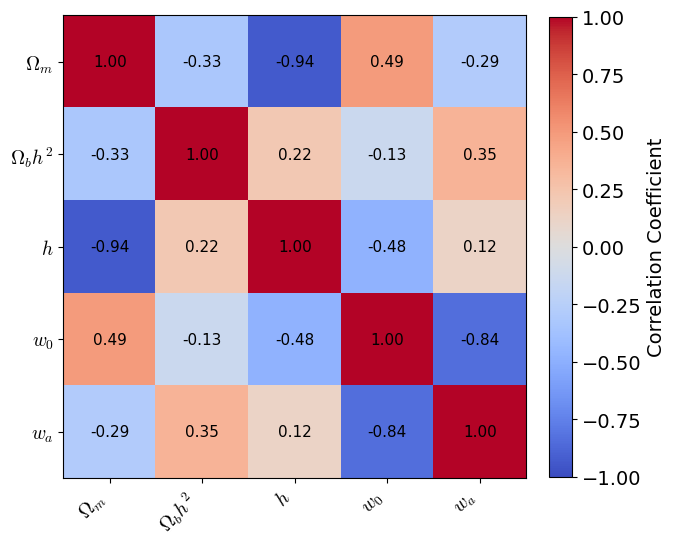

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# Matplotlib settings
# ============================================================
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.size'] = 14

# ============================================================
# Load covariance matrix
# ============================================================
cov = np.loadtxt("/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/baCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc.covmat", delimiter=",")

print("Covariance matrix shape:", cov.shape)
print(cov)

# ============================================================
# Parameter labels
# ============================================================
labels = [r'$\Omega_m$', r'$\Omega_b h^2$', r'$h$', r'$w_0$', r'$w_a$']

# ============================================================
# Convert covariance matrix to correlation matrix
# ============================================================
sigma = np.sqrt(np.diag(cov))
corr = cov / np.outer(sigma, sigma)

print("\nCorrelation matrix:")
print(corr)

# ============================================================
# Plot correlation matrix
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, fontsize=14, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=14)

# Write correlation values inside cells
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(
            j, i,
            f"{corr[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=11,
            color='black'
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.90,pad=0.04)
cbar.set_label('Correlation Coefficient', fontsize=14)
plt.tight_layout()

# Save figure
plt.savefig("BA_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

# JBP

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots, MCSamples

# ============================================================
# 1. Load samples
# ============================================================

# Load chains data for CPL model
data1 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt')
data2 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt')
data3 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt') 

# Extract weights (column 0)
weights1 = data1[:, 0]
weights2 = data2[:, 0]
weights3 = data3[:, 0]

# Extract cosmological parameters (columns 2-6: Om, Obh2, h, w0, wa)
params1 = data1[:, 2:7]
params2 = data2[:, 2:7]
params3 = data3[:, 2:7]

# Define parameter names and labels
param_names = ['Om', 'Obh2', 'h', 'w0', 'wa']
param_labels = [r'\Omega_m', r'\Omega_b h^2', r'h', r'w_0', r'w_a']

# Create MCSamples objects
samples1 = MCSamples(samples=params1, weights=weights1, names=param_names, labels=param_labels)
samples2 = MCSamples(samples=params2, weights=weights2, names=param_names, labels=param_labels)
samples3 = MCSamples(samples=params3, weights=weights3, names=param_names, labels=param_labels)

samples_list = [samples1, samples2, samples3]

labels = [
    "PLK18+DESIDR2+PantheonPlus",
    "PLK18+DESIDR2+Union3",
    "PLK18+DESIDR2+DESY5"
]

Removed no burn in
Removed no burn in
Removed no burn in


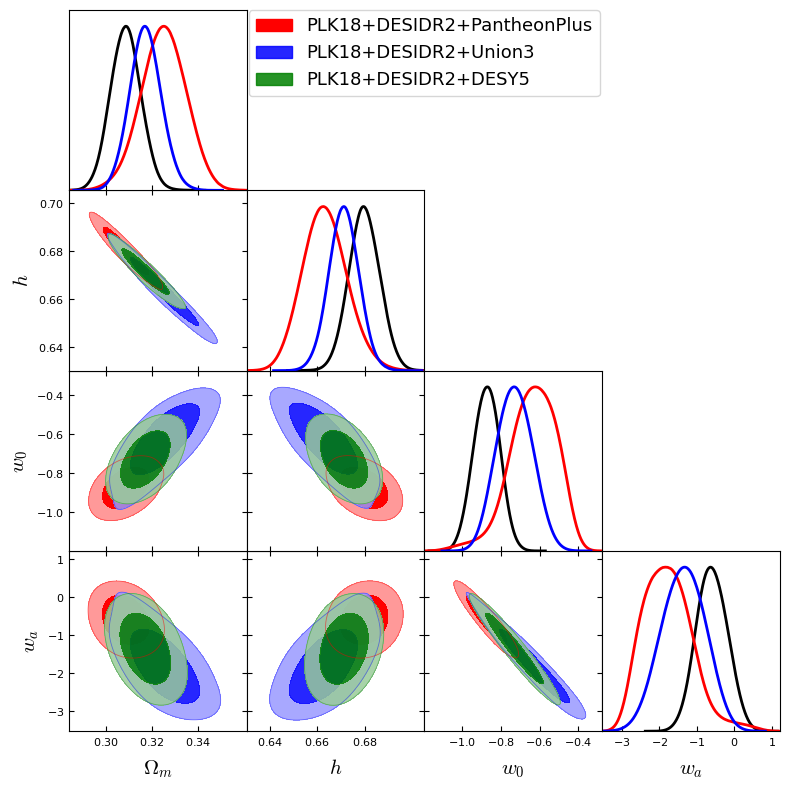

In [11]:
# ============================================================
# 2. Triangle plot
# ============================================================

params = ['Om', 'h', 'w0', 'wa']

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize  = 18
g.settings.lab_fontsize   = 18

g.triangle_plot(
    samples_list,
    params,
    filled=True,
    legend_labels=labels,
    contour_colors=["red", "blue", "green"],
    line_args=[
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2}
    ]
)

plt.savefig("combined_jbp_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
import glob

# Adjust these paths to your actual chain root names
chain_roots = {
    "PLK18+DESIDR2+PantheonPlus": "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1",
    "PLK18+DESIDR2+Union3":       "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1",
    "PLK18+DESIDR2+DESY5":        "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1",
}

def get_chi2_min_from_files(chain_root):
    files = sorted(glob.glob(chain_root + "_*.txt"))
    if not files:
        # try without numbering
        files = [chain_root + ".txt"]
    print(f"  Found {len(files)} chain file(s): {files}")
    
    all_loglikes = []
    for f in files:
        raw = np.loadtxt(f)
        all_loglikes.append(raw[:, 1])   # column 1 = -loglike
    
    combined = np.concatenate(all_loglikes)
    return 2.0 * np.min(combined)

# ============================================================
# ============================================================
# 4. Model complexity and data size
# ============================================================

# Number of free parameters in ΛCDM
k_jbp = 4   # H0, Omegab0, Omegam0, od0

# Number of data points
N_values = {
    "PLK18+DESIDR2+PantheonPlus": 1701 + 0 + 13,   # 1717
    "PLK18+DESIDR2+Union3":   1829 + 0 + 13,   # 1845
    "PLK18+DESIDR2+DESY5":            0 + 13 + 2087          # 16
}

results = []
for label in labels:
    print(f"\n{label}")
    chi2_min = get_chi2_min_from_files(chain_roots[label])
    N = N_values[label]
    AIC = chi2_min + 2 * k_jbp
    BIC = chi2_min + k_jbp * np.log(N)
    results.append((label, chi2_min, AIC, BIC))
    print(f"chi2_min = {chi2_min:.3f}")
    print(f"AIC      = {AIC:.3f}")
    print(f"BIC      = {BIC:.3f}")
    
    # ---- Text file ----
with open("jbp_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

# ---- LaTeX table ----
with open("jbp_AIC_BIC.tex", "w") as f:
    f.write(r"\begin{tabular}{lccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & $\chi^2_{\min}$ & AIC & BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label} & {chi2:.2f} & {aic:.2f} & {bic:.2f} \\\\\n")
    f.write(r"\hline" + "\n")
    f.write(r"\end{tabular}" + "\n")

# ============================================================
# 7. Print selected parameter constraints
# ============================================================
'Om', 'h', 'w0', 'wa'
for s, l in zip(samples_list, labels):
    print(f"\nParameter constraints for {l}:")
    print(s.getInlineLatex('Om', limit=1))
    print(s.getInlineLatex('h', limit=1))
    print(s.getInlineLatex('w0', limit=1))
    print(s.getInlineLatex('wa', limit=1))


PLK18+DESIDR2+PantheonPlus
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt']
chi2_min = 1412.614
AIC      = 1420.614
BIC      = 1442.400

PLK18+DESIDR2+Union3
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt']
chi2_min = 29.122
AIC      = 37.122
BIC      = 59.197

PLK18+DESIDR2+DESY5
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/jbpCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt']
chi2_min = 1646.178
AIC      = 1654.178
BIC      = 1676.777

Parameter constraints for PLK18+DESIDR2+PantheonPlus:
\Omega_m = 0.3086\pm 0.0066
h = 0.6799\pm 0.0065
w_0 = -0.875\pm 0.068
w_a = -0.60\pm 0.41

Parameter constraints for PLK18+DESIDR2+Union3:
\Omega_m = 0.3249\pm 0.0097
h = 0.6633^{+0.0088}_{-0.0099}
w_0 = -0.63^{+0.14}_{-0.10}
w_a = -1.78^{+0.55}_{-0.73}

Parameter constraints for PL

# LOG

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots, MCSamples

# ============================================================
# 1. Load samples
# ============================================================

# Load chains data for CPL model
data1 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt')
data2 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt')
data3 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt') 

# Extract weights (column 0)
weights1 = data1[:, 0]
weights2 = data2[:, 0]
weights3 = data3[:, 0]

# Extract cosmological parameters (columns 2-6: Om, Obh2, h, w0, wa)
params1 = data1[:, 2:7]
params2 = data2[:, 2:7]
params3 = data3[:, 2:7]

# Define parameter names and labels
param_names = ['Om', 'Obh2', 'h', 'w0', 'wa']
param_labels = [r'\Omega_m', r'\Omega_b h^2', r'h', r'w_0', r'w_a']

# Create MCSamples objects
samples1 = MCSamples(samples=params1, weights=weights1, names=param_names, labels=param_labels)
samples2 = MCSamples(samples=params2, weights=weights2, names=param_names, labels=param_labels)
samples3 = MCSamples(samples=params3, weights=weights3, names=param_names, labels=param_labels)

samples_list = [samples1, samples2, samples3]

labels = [
    "PLK18+DESIDR2+PantheonPlus",
    "PLK18+DESIDR2+Union3",
    "PLK18+DESIDR2+DESY5"
]

Removed no burn in
Removed no burn in
Removed no burn in


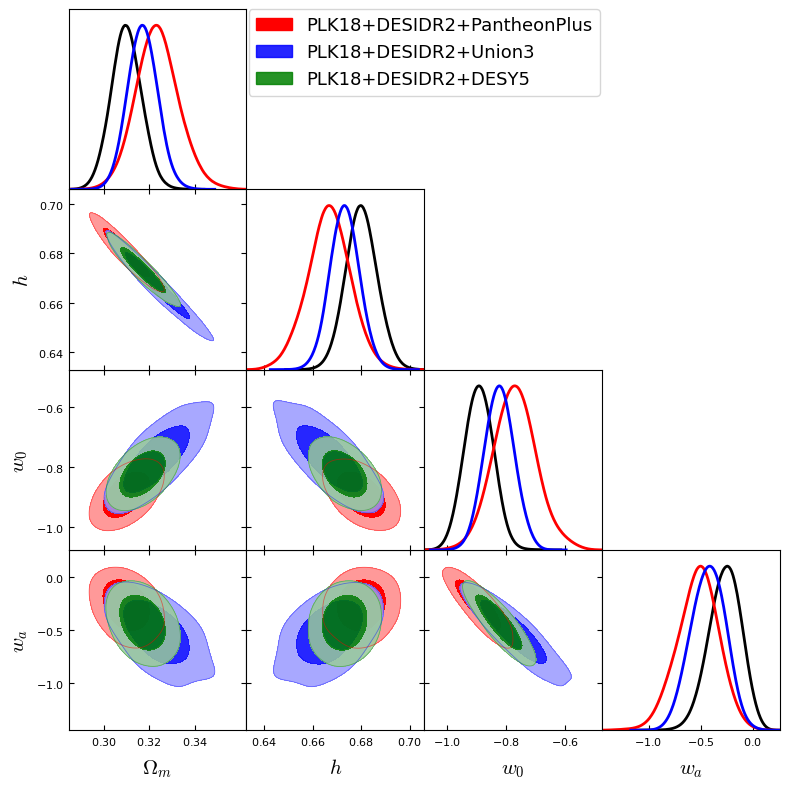

In [14]:
# ============================================================
# 2. Triangle plot
# ============================================================

params = ['Om', 'h', 'w0', 'wa']

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize  = 18
g.settings.lab_fontsize   = 18

g.triangle_plot(
    samples_list,
    params,
    filled=True,
    legend_labels=labels,
    contour_colors=["red", "blue", "green"],
    line_args=[
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2}
    ]
)

plt.savefig("combined_log_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
import glob

# Adjust these paths to your actual chain root names
chain_roots = {
    "PLK18+DESIDR2+PantheonPlus": "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1",
    "PLK18+DESIDR2+Union3":       "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1",
    "PLK18+DESIDR2+DESY5":        "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1",
}

def get_chi2_min_from_files(chain_root):
    files = sorted(glob.glob(chain_root + "_*.txt"))
    if not files:
        # try without numbering
        files = [chain_root + ".txt"]
    print(f"  Found {len(files)} chain file(s): {files}")
    
    all_loglikes = []
    for f in files:
        raw = np.loadtxt(f)
        all_loglikes.append(raw[:, 1])   # column 1 = -loglike
    
    combined = np.concatenate(all_loglikes)
    return 2.0 * np.min(combined)

# ============================================================
# ============================================================
# 4. Model complexity and data size
# ============================================================

# Number of free parameters in ΛCDM
k_log = 4   # H0, Omegab0, Omegam0, od0

# Number of data points
N_values = {
    "PLK18+DESIDR2+PantheonPlus": 1701 + 0 + 13,   # 1717
    "PLK18+DESIDR2+Union3":   1829 + 0 + 13,   # 1845
    "PLK18+DESIDR2+DESY5":            0 + 13 + 2087          # 16
}

results = []
for label in labels:
    print(f"\n{label}")
    chi2_min = get_chi2_min_from_files(chain_roots[label])
    N = N_values[label]
    AIC = chi2_min + 2 * k_log
    BIC = chi2_min + k_log * np.log(N)
    results.append((label, chi2_min, AIC, BIC))
    print(f"chi2_min = {chi2_min:.3f}")
    print(f"AIC      = {AIC:.3f}")
    print(f"BIC      = {BIC:.3f}")
    
    # ---- Text file ----
with open("log_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

# ---- LaTeX table ----
with open("log_AIC_BIC.tex", "w") as f:
    f.write(r"\begin{tabular}{lccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & $\chi^2_{\min}$ & AIC & BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label} & {chi2:.2f} & {aic:.2f} & {bic:.2f} \\\\\n")
    f.write(r"\hline" + "\n")
    f.write(r"\end{tabular}" + "\n")

# ============================================================
# 7. Print selected parameter constraints
# ============================================================
'Om', 'h', 'w0', 'wa'
for s, l in zip(samples_list, labels):
    print(f"\nParameter constraints for {l}:")
    print(s.getInlineLatex('Om', limit=1))
    print(s.getInlineLatex('h', limit=1))
    print(s.getInlineLatex('w0', limit=1))
    print(s.getInlineLatex('wa', limit=1))


PLK18+DESIDR2+PantheonPlus
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt']
chi2_min = 1411.536
AIC      = 1419.536
BIC      = 1441.322

PLK18+DESIDR2+Union3
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt']
chi2_min = 29.460
AIC      = 37.460
BIC      = 59.534

PLK18+DESIDR2+DESY5
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/logCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt']
chi2_min = 1646.404
AIC      = 1654.404
BIC      = 1677.003

Parameter constraints for PLK18+DESIDR2+PantheonPlus:
\Omega_m = 0.3099\pm 0.0067
h = 0.6800\pm 0.0065
w_0 = -0.892\pm 0.050
w_a = -0.27^{+0.17}_{-0.15}

Parameter constraints for PLK18+DESIDR2+Union3:
\Omega_m = 0.3235^{+0.0088}_{-0.0099}
h = 0.6667\pm 0.0089
w_0 = -0.771\pm 0.074
w_a = -0.53^{+0.21}_{-0.18}

Parameter constraints for 

# $\omega$ CDM

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots, MCSamples

# ============================================================
# 1. Load samples
# ============================================================

# Load chains data for CPL model
data1 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt')
data2 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt')
data3 = np.loadtxt('/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt') 

# Extract weights (column 0)
weights1 = data1[:, 0]
weights2 = data2[:, 0]
weights3 = data3[:, 0]

# Extract cosmological parameters (columns 2-6: Om, Obh2, h, w0, wa)
params1 = data1[:, 2:7]
params2 = data2[:, 2:7]
params3 = data3[:, 2:7]

# Define parameter names and labels
param_names = ['Om', 'Obh2', 'h', 'w0', 'wa']
param_labels = [r'\Omega_m', r'\Omega_b h^2', r'h', r'w_0', r'w_a']

# Create MCSamples objects
samples1 = MCSamples(samples=params1, weights=weights1, names=param_names, labels=param_labels)
samples2 = MCSamples(samples=params2, weights=weights2, names=param_names, labels=param_labels)
samples3 = MCSamples(samples=params3, weights=weights3, names=param_names, labels=param_labels)

samples_list = [samples1, samples2, samples3]

labels = [
    "PLK18+DESIDR2+PantheonPlus",
    "PLK18+DESIDR2+Union3",
    "PLK18+DESIDR2+DESY5"
]

Removed no burn in
Removed no burn in
Removed no burn in


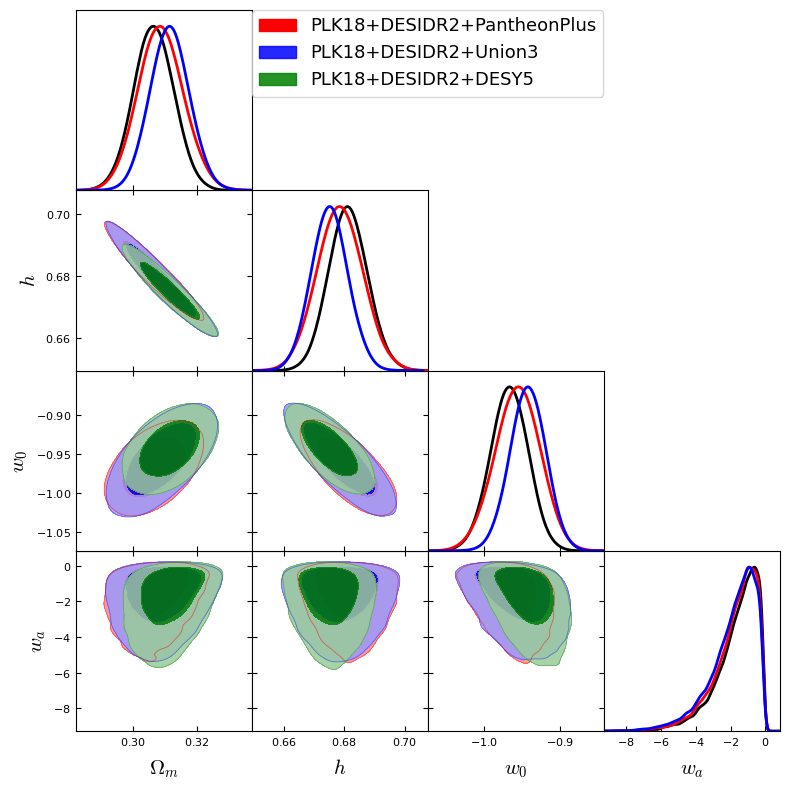

In [20]:
# ============================================================
# 2. Triangle plot
# ============================================================

params = ['Om', 'h', 'w0', 'wa']

g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 16
g.settings.axes_labelsize  = 18
g.settings.lab_fontsize   = 18

g.triangle_plot(
    samples_list,
    params,
    filled=True,
    legend_labels=labels,
    contour_colors=["red", "blue", "green"],
    line_args=[
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2},
        {"ls": "-", "lw": 2}
    ]
)

plt.savefig("combined_wcdm_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
import glob

# Adjust these paths to your actual chain root names
chain_roots = {
    "PLK18+DESIDR2+PantheonPlus": "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1",
    "PLK18+DESIDR2+Union3":       "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1",
    "PLK18+DESIDR2+DESY5":        "/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1",
}

def get_chi2_min_from_files(chain_root):
    files = sorted(glob.glob(chain_root + "_*.txt"))
    if not files:
        # try without numbering
        files = [chain_root + ".txt"]
    print(f"  Found {len(files)} chain file(s): {files}")
    
    all_loglikes = []
    for f in files:
        raw = np.loadtxt(f)
        all_loglikes.append(raw[:, 1])   # column 1 = -loglike
    
    combined = np.concatenate(all_loglikes)
    return 2.0 * np.min(combined)

# ============================================================
# ============================================================
# 4. Model complexity and data size
# ============================================================

# Number of free parameters in ΛCDM
k_w = 4   # H0, Omegab0, Omegam0, od0

# Number of data points
N_values = {
    "PLK18+DESIDR2+PantheonPlus": 1701 + 0 + 13,   # 1717
    "PLK18+DESIDR2+Union3":   1829 + 0 + 13,   # 1845
    "PLK18+DESIDR2+DESY5":            0 + 13 + 2087          # 16
}

results = []
for label in labels:
    print(f"\n{label}")
    chi2_min = get_chi2_min_from_files(chain_roots[label])
    N = N_values[label]
    AIC = chi2_min + 2 * k_w
    BIC = chi2_min + k_w * np.log(N)
    results.append((label, chi2_min, AIC, BIC))
    print(f"chi2_min = {chi2_min:.3f}")
    print(f"AIC      = {AIC:.3f}")
    print(f"BIC      = {BIC:.3f}")
    
    # ---- Text file ----
with open("wcdm_AIC_BIC.txt", "w") as f:
    f.write("Dataset\tchi2_min\tAIC\tBIC\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label}\t{chi2:.3f}\t{aic:.3f}\t{bic:.3f}\n")

# ---- LaTeX table ----
with open("wcdm_AIC_BIC.tex", "w") as f:
    f.write(r"\begin{tabular}{lccc}" + "\n")
    f.write(r"\hline" + "\n")
    f.write(r"Dataset & $\chi^2_{\min}$ & AIC & BIC \\" + "\n")
    f.write(r"\hline" + "\n")
    for label, chi2, aic, bic in results:
        f.write(f"{label} & {chi2:.2f} & {aic:.2f} & {bic:.2f} \\\\\n")
    f.write(r"\hline" + "\n")
    f.write(r"\end{tabular}" + "\n")

# ============================================================
# 7. Print selected parameter constraints
# ============================================================
'Om', 'h', 'w0', 'wa'
for s, l in zip(samples_list, labels):
    print(f"\nParameter constraints for {l}:")
    print(s.getInlineLatex('Om', limit=1))
    print(s.getInlineLatex('h', limit=1))
    print(s.getInlineLatex('w0', limit=1))
    print(s.getInlineLatex('wa', limit=1))


PLK18+DESIDR2+PantheonPlus
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+PantheonPlus_mcmc_1.txt']
chi2_min = 1414.340
AIC      = 1422.340
BIC      = 1444.126

PLK18+DESIDR2+Union3
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+Union3_mcmc_1.txt']
chi2_min = 36.543
AIC      = 44.543
BIC      = 66.617

PLK18+DESIDR2+DESY5
  Found 1 chain file(s): ['/home/cosubhasmos/workspace/cosmology/Quintom/paper/chains/wCDMCosmology_phy_PLK18+DESIDR2+DESY5_mcmc_1.txt']
chi2_min = 1653.116
AIC      = 1661.116
BIC      = 1683.715

Parameter constraints for PLK18+DESIDR2+PantheonPlus:
\Omega_m = 0.3064\pm 0.0064
h = 0.6813\pm 0.0065
w_0 = -0.967\pm 0.025
w_a = -1.63^{+1.5}_{-0.41}

Parameter constraints for PLK18+DESIDR2+Union3:
\Omega_m = 0.3086\pm 0.0072
h = 0.6786\pm 0.0076
w_0 = -0.956\pm 0.030
w_a = -1.73^{+1.5}_{-0.44}

Parameter constraints for PLK18+DES